<a href="https://colab.research.google.com/github/ZanebRA/urdu-ocr-codesaviours-si26-zaneb/blob/main/SI26_Week1_Zaneb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1 Research Task

## 1. What is OCR (Optical Character Recognition)?

OCR (Optical Character Recognition) is a technology that converts text from images into editable and searchable digital text. It helps computers recognize printed or handwritten characters from scanned documents or photos. OCR is widely used to digitize books, forms, invoices, and other paper documents.

---

## 2. Why is Urdu OCR harder than English OCR?

Urdu OCR is more difficult because Urdu is written from right to left and many letters change their shape depending on their position in a word. Some Urdu letters look very similar, which makes them harder for a computer to recognize correctly. Different writing styles, fonts, and image quality also make Urdu OCR more challenging than English OCR.

---

## 3. What are two real-world situations where Urdu OCR would be useful?

Urdu OCR can be used to convert old Urdu books and newspapers into digital text so they can be searched and preserved. It can also help organizations digitize printed Urdu documents such as government records, forms, and educational material, making them easier to store and access.

In [7]:
import os

folders = [
    'data/raw/newspaper',
    'data/raw/books',
    'data/raw/signboards',
    'data/raw/synthetic',
    'data/raw/other'
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f'Created: {folder}')

print('Folder structure ready!')

Created: data/raw/newspaper
Created: data/raw/books
Created: data/raw/signboards
Created: data/raw/synthetic
Created: data/raw/other
Folder structure ready!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import shutil
# Source folder in Google Drive
source_folder = "/content/drive/MyDrive/UNHD-Complete-Data"

# Destination folder in Colab
destination_folder = "data/raw/other"

# Get only PNG images
png_files = sorted([f for f in os.listdir(source_folder) if f.endswith(".png")])

# Copy first 50 PNG images
for file in png_files[:50]:
    shutil.copy(
        os.path.join(source_folder, file),
        os.path.join(destination_folder, file)
    )
print(f"✅ Copied {len(png_files[:50])} PNG images to {destination_folder}")

✅ Copied 50 PNG images to data/raw/other


In [21]:
# Install required libraries and Urdu font
!pip -q install pillow arabic-reshaper python-bidi
!apt-get -qq update
!apt-get -qq install -y fonts-noto-core

# Import required libraries
from PIL import Image, ImageDraw, ImageFont
import arabic_reshaper
from bidi.algorithm import get_display
import os

# Create output folder
output_folder = "data/raw/synthetic"
os.makedirs(output_folder, exist_ok=True)

# Sample Urdu text sentences
urdu_texts = [
    "پاکستان زندہ باد",
    "آج کا موسم خوشگوار ہے",
    "تعلیم ہر انسان کا حق ہے",
    "کراچی پاکستان کا سب سے بڑا شہر ہے",
    "محنت کامیابی کی کنجی ہے",
    "زندگی ایک خوبصورت سفر ہے",
    "علم روشنی ہے",
    "وقت سب سے قیمتی چیز ہے",
    "صبر کامیابی کی علامت ہے",
    "محبت ایک خوبصورت جذبہ ہے",
    "دوستی زندگی کا حسن ہے",
    "ماں کی دعا جنت ہے",
    "کتاب بہترین دوست ہے",
    "محنت کا پھل میٹھا ہوتا ہے",
    "سچائی ہمیشہ کامیاب ہوتی ہے",
    "حوصلہ کامیابی دیتا ہے",
    "علم انسان کو بلند کرتا ہے",
    "وقت ضائع نہ کرو",
    "خوش رہو اور خوشیاں بانٹو",
    "ہر مشکل کے بعد آسانی ہے"
]

# Load Urdu font
font_path = "/usr/share/fonts/truetype/noto/NotoNaskhArabic-Regular.ttf"
font = ImageFont.truetype(font_path, 30)

# Generate synthetic images
for i, text in enumerate(urdu_texts, start=1):

    # 1. Reshape the Arabic/Urdu characters to their correct connected forms
    reshaped_text = arabic_reshaper.reshape(text)

    # 2. Apply BiDi algorithm to handle correct right-to-left character ordering
    bidi_text = get_display(reshaped_text)

    # Create a blank white canvas image
    img = Image.new("RGB", (650, 150), "white")
    draw = ImageDraw.Draw(img)

    # 3. Draw text without explicit direction tag to avoid environment layout conflicts
    draw.text(
        (630, 50),
        bidi_text,
        font=font,
        fill="black",
        anchor="rt"
    )

    # Save the finalized image
    img.save(f"{output_folder}/urdu_{i}.png")

    print(f"Generated: urdu_{i}.png -> {text}")

print("\n 20 synthetic Urdu images generated successfully!")
print(" Images saved in: data/raw/synthetic")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Generated: urdu_1.png -> پاکستان زندہ باد
Generated: urdu_2.png -> آج کا موسم خوشگوار ہے
Generated: urdu_3.png -> تعلیم ہر انسان کا حق ہے
Generated: urdu_4.png -> کراچی پاکستان کا سب سے بڑا شہر ہے
Generated: urdu_5.png -> محنت کامیابی کی کنجی ہے
Generated: urdu_6.png -> زندگی ایک خوبصورت سفر ہے
Generated: urdu_7.png -> علم روشنی ہے
Generated: urdu_8.png -> وقت سب سے قیمتی چیز ہے
Generated: urdu_9.png -> صبر کامیابی کی علامت ہے
Generated: urdu_10.png -> محبت ایک خوبصورت جذبہ ہے
Generated: urdu_11.png -> دوستی زندگی کا حسن ہے
Generated: urdu_12.png -> ماں کی دعا جنت ہے
Generated: urdu_13.png -> کتاب بہترین دوست ہے
Generated: urdu_14.png -> محنت کا پھل میٹھا ہوتا ہے
Generated: urdu_15.png -> سچائی ہمیشہ کامیاب ہوتی ہے
Generated: urdu_16.png -> حوصلہ کامیابی دیتا ہے
Generated: urdu_17.png -> علم انسان کو

In [9]:
import csv

# Master list containing all data from books, newspaper, and synthetic folders
labels = [
    # === BOOKS FOLDER ===
    {"image": "data/raw/books/Screenshot (1250).png", "text": "سامنے کا منظر اس ننھی بچی کے دل کو چیر گیا تھا"},
    {"image": "data/raw/books/Screenshot (1253).png", "text": "مگر اس کی فریاد سننے والا کوئی نہ تھا"},
    {"image": "data/raw/books/Screenshot (1254).png", "text": "یہ سب اس کی وجہ سے ہوا تھا"},
    {"image": "data/raw/books/Screenshot (1255).png", "text": "کیونکہ تقریباً کلاسز ختم ہو چکی تھیں"},
    {"image": "data/raw/books/Screenshot (1257).png", "text": "مہرزلہ برلاس کا اسی شہر سے دم گھٹتا تھا"},
    {"image": "data/raw/books/Screenshot (1258).png", "text": "ادھیڑ عمر شخص جو کہ بادام خان اس کے دادا کا وفادار"},
    {"image": "data/raw/books/Screenshot (1259).png", "text": "مہرزلہ۔۔۔!!! کسی نے پیچھے سے آتے اسے جھنجھوڑا تھا"},
    {"image": "data/raw/books/Screenshot (1260).png", "text": "شام کے چار بج رہے تھے"},
    {"image": "data/raw/books/Screenshot (1261).png", "text": "اس کے چہرے پر بلا کی سختی تھی"},
    {"image": "data/raw/books/Screenshot (1262).png", "text": "اور پھر اس عقوبت خانے کی طرف واپسی کا سفر شروع ہو چکا"},

    # === NEWSPAPER FOLDER ===
    {"image": "data/raw/newspaper/Screenshot (1242).png", "text": "بحیرہ عرب میں امریکی ہیلی کاپٹر حادثے کا شکار"},
    {"image": "data/raw/newspaper/Screenshot (1244).png", "text": "دوحہ میں امریکہ اور ایران کے درمیان بالواسطہ مذاکرات میں پیش رفت"},
    {"image": "data/raw/newspaper/Screenshot (1245).png", "text": "برطانیہ میں 26 سال بعد ایک ماہ کے دوران ڈیزل کی قیمت میں بڑی"},
    {"image": "data/raw/newspaper/Screenshot (1246).png", "text": "ہمیں تنگ کرنا اور ٹرمپ کے الفاظ دہرانا بند کریں"},
    {"image": "data/raw/newspaper/Screenshot (1247).png", "text": "صدر ٹرمپ کسی واضح مقصد کے بغیر ایران میں دوبارہ فوجی کارروائی"},
    {"image": "data/raw/newspaper/Screenshot (1249).png", "text": "یوکرین کے دارالحکومت کیئو میں روسی میزائل اور ڈرون حملہ، کم از کم 13 افراد ہلاک"},
    {"image": "data/raw/newspaper/Screenshot (1250)_2.png", "text": "پاکستان اور سعودی عرب کے درمیان سیکیورٹی کے شعبے میں مفاہمتی یادداشت پر دستخط"},
    {"image": "data/raw/newspaper/Screenshot (1251).png", "text": "پاکستان کے مختلف شہروں میں 48 گھنٹوں کے دوران تیز آندھی"},
    {"image": "data/raw/newspaper/Screenshot (1252).png", "text": "شہباز شریف علی خامنہ ای کی نماز جنازہ میں شرکت کریں گے"},
    {"image": "data/raw/newspaper/Screenshot (1253)_2.png", "text": "لاہور کے علاقے باغبانپورہ میں زیر تعمیر عمارت کی چھت گرنے سے 10 سالہ بچہ ہلاک ہو گیا جبکہ چار افراد زخمی ہو گئے۔"},

    # === SYNTHETIC FOLDER ===
    {"image": "data/raw/synthetic/urdu_1.png", "text": "پاکستان زندہ باد"},
    {"image": "data/raw/synthetic/urdu_2.png", "text": "آج کا موسم خوشگوار ہے"},
    {"image": "data/raw/synthetic/urdu_3.png", "text": "تعلیم ہر انسان کا حق ہے"},
    {"image": "data/raw/synthetic/urdu_4.png", "text": "کراچی پاکستان کا سب سے بڑا شہر ہے"},
    {"image": "data/raw/synthetic/urdu_5.png", "text": "محنت کامیابی کی کنجی ہے"},
    {"image": "data/raw/synthetic/urdu_6.png", "text": "زندگی ایک خوبصورت سفر ہے"},
    {"image": "data/raw/synthetic/urdu_7.png", "text": "علم روشنی ہے"},
    {"image": "data/raw/synthetic/urdu_8.png", "text": "وقت سب سے قیمتی چیز ہے"},
    {"image": "data/raw/synthetic/urdu_9.png", "text": "صبر کامیابی کی علامت ہے"},
    {"image": "data/raw/synthetic/urdu_10.png", "text": "محبت ایک خوبصورت جذبہ ہے"},
    {"image": "data/raw/synthetic/urdu_11.png", "text": "دوستی زندگی کا حسن ہے"},
    {"image": "data/raw/synthetic/urdu_12.png", "text": "ماں کی دعا جنت ہے"},
    {"image": "data/raw/synthetic/urdu_13.png", "text": "کتاب بہترین دوست ہے"},
    {"image": "data/raw/synthetic/urdu_14.png", "text": "محنت کا پھل میٹھا ہوتا ہے"},
    {"image": "data/raw/synthetic/urdu_15.png", "text": "سچائی ہمیشہ کامیاب ہوتی ہے"},
    {"image": "data/raw/synthetic/urdu_16.png", "text": "حوصلہ کامیابی دیتا ہے"},
    {"image": "data/raw/synthetic/urdu_17.png", "text": "علم انسان کو بلند کرتا ہے"},
    {"image": "data/raw/synthetic/urdu_18.png", "text": "وقت ضائع نہ کرو"},
    {"image": "data/raw/synthetic/urdu_19.png", "text": "خوش رہو اور خوشیاں بانٹو"},
    {"image": "data/raw/synthetic/urdu_20.png", "text": "ہر مشکل کے بعد آسانی ہے"},

    # === SIGNBOARDS FOLDER ===
    {"image": "data/raw/signboards/13.jpg", "text": "النس الیکٹرک سٹور"},
    {"image": "data/raw/signboards/14.jpg", "text": "زمان اسٹیٹ اینڈ پراپرٹی ایجنسی"},
    {"image": "data/raw/signboards/15.jpg", "text": "زمان پراپرٹی ایڈوائزر"},
    {"image": "data/raw/signboards/16.jpg", "text": "ریحم بیوٹی سیلون اینڈ لیڈیز ٹیلرنگ"},
    {"image": "data/raw/signboards/17.jpg", "text": "زمان اسٹیٹ ایڈوائزر"},
    {"image": "data/raw/signboards/18.jpg", "text": "الیغروز پرنٹرز اینڈ پینا فلیکس"},
    {"image": "data/raw/signboards/19.jpg", "text": "حسنین ٹریڈرز اینڈ الیکٹرک سٹور"},
    {"image": "data/raw/signboards/20.jpg", "text": "چکی کے اسپیشل مصالحہ جات"},
    {"image": "data/raw/signboards/21.jpg", "text": "مدینہ چکن شاپ ہول سیل ڈیلر"},
    {"image": "data/raw/signboards/22.jpg", "text": "مدینہ چکن شاپ ہول سیل"},

    # === OTHER FOLDER ===
    {"image": "data/raw/other/001_001_1.png", "text": "کون سوچ سکتا تھا کہ ہندوستان اکثریت اور انگریز حکمرانوں کی مشترکہ"},
    {"image": "data/raw/other/001_001_2.png", "text": "مخالفت کے باوجود معرض وجود میں اسلام ہے اور اسی نظریہ"},
    {"image": "data/raw/other/001_001_3.png", "text": "یہ اس ملک میں بسنے والے مختلف عناصر کا اتحاد ہے اور پاکستان کی"},
    {"image": "data/raw/other/001_001_4.png", "text": "بقا اسی نظریے حیات کے فروغ پر منحصر ہے ۔"},
    {"image": "data/raw/other/001_001_5.png", "text": "لیکن بدقسمتی سے پاکستان بننے کے بعد ہی اس کے اندر ایسے دشمن"},
    {"image": "data/raw/other/001_001_6.png", "text": "عناصر جو اس مملکت کے بنیادی نظریہ پر ایمان نہیں رکھتے تھے ۔ وہ"},
    {"image": "data/raw/other/001_001_7.png", "text": "پاکستان کے نظریے پاکستان کا مطلب کیا لا الہ الا اللہ میں رخنہ فارما"},
    {"image": "data/raw/other/001_001_8.png", "text": "کی طرح شامل ہو گئے جبکہ ایک دوسرا طبقہ نیمت آزادی کے پھل سمیٹنے"},
    {"image": "data/raw/other/001_002_1.png", "text": "میں مصروف ہو گیا بغیر اس کا انعام کئے کہ جس کا وہ پھل کھا رہا ہے"},
    {"image": "data/raw/other/001_002_2.png", "text": "اس کو پانی دینے اور مضبوط کرنے کی بھی اشد ضرورت ہے۔ پاکستان"},
    {"image": "data/raw/other/001_002_3.png", "text": "کے معرض وجود میں آنے سے پہلے مسلمانوں کے سیاسی دور کا آغاز"},
    {"image": "data/raw/other/001_002_4.png", "text": "کچھ حوصلہ افراد نہ تھا۔ رنجیت سنگھ تھا اسی نے اپنی ایک علیحدہ"},
    {"image": "data/raw/other/001_002_5.png", "text": "سکھ سلطنت قائم کی تھی۔ سکھ سلطنت میں بھارت پنجاب، پاکستانی"},
    {"image": "data/raw/other/001_002_6.png", "text": "پنجاب، کشمیر، صوبہ خیبر پختونخوا اور گلگت بلتستان شامل تھے مگر رنجیت"},
    {"image": "data/raw/other/001_002_7.png", "text": "سنگھ کے مرنے کے بعد انگریزوں نے اس سلطنت کو ہتھیا لیا۔ اس کے بعد"},
    {"image": "data/raw/other/001_002_8.png", "text": "ڈاکٹر علامہ اقبال کا بھی تاریخ پاکستان میں بڑا مثبت کردار تھا۔"},
    {"image": "data/raw/other/001_003_1.png", "text": "کیا پاکستانی سیاست میں نئی لہر میں لیڈرس کو لانا چاہتے ہے"},
    {"image": "data/raw/other/001_003_2.png", "text": "جو جوش خطابت میں عوام کو خواب دکھائے ، مسیحا بن کے نعرے بازی کرے،"},
    {"image": "data/raw/other/001_003_3.png", "text": "حریف سیاستدانوں پر کیچڑ اچھالے یا خوف طاری کرنے کی کوشش کرے،"},
    {"image": "data/raw/other/001_003_4.png", "text": "سیاسی جلسے میں بیروزگار نوجوانوں کو دہاڑی پر لے آئے ، زہریلے سانپ"},
    {"image": "data/raw/other/001_003_5.png", "text": "لئے نظر آئے۔ اپنی تقریر اپنے سلام سے شروع کروائے، سیاست میں کاروباری"},
    {"image": "data/raw/other/001_003_6.png", "text": "داؤ پیچ سکھائے ، ذاتی مفاد میں امریکہ کے سفارتخانے کے عقبی دروازے سے"},
    {"image": "data/raw/other/001_003_7.png", "text": "تشریف لے جائے، شاہراہِ دستور پر سفر کرے تو عام شہریوں کو دھکے پڑیں کیا"},
    {"image": "data/raw/other/001_003_8.png", "text": "دے، اپنے خاندان کو خوشگوار زندگی گزارنے کے لیے وطن سے باہر منتقل کر دے۔"},
    {"image": "data/raw/other/001_004_1.png", "text": "۱۹۴۷ سے قبل پاکستانی علاقہ مختلف بادشاہوں اور علاقائی طاقتوں"},
    {"image": "data/raw/other/001_004_2.png", "text": "کے زیر اثر رہا۔ یہ پاکستانی علاقہ پرانی تہذیب و تمدن کا گہوارہ رہا ہے"},
    {"image": "data/raw/other/001_004_3.png", "text": "۱۸۵۷ کی جنگ آزادی کے بعد مسلمانوں میں احساس محرومی وقت کے"},
    {"image": "data/raw/other/001_004_4.png", "text": "ساتھ ساتھ بڑھتا گیا۔ مسلمانوں کے حقوق کے تحفظ کیلئے ۱۹۰۶ میں"},
    {"image": "data/raw/other/001_004_5.png", "text": "آل انڈیا مسلم لیگ کا قیام وجود میں آیا۔ مسلم لیگ کے پلیٹ فارم سے"},
    {"image": "data/raw/other/001_004_6.png", "text": "سرعلامہ محمد اقبال نے ۱۹۳۰ میں علیحدہ ریاست کا خیال پیش"},
    {"image": "data/raw/other/001_004_7.png", "text": "کیا جو مسلمانوں کے حقوق کے تحفظ کے لیے ایک اہم قدم تھا۔ قائد اعظم"},
    {"image": "data/raw/other/001_004_8.png", "text": "نے قومی نظریہ ۲۳ مارچ ۱۹۴۰ کو قرار داد لاہور میں قائد اعظم محمد علی"},
    {"image": "data/raw/other/001_005_1.png", "text": "جناح نے پیش کیا ۔ بالا دو قومی نظریے کی بنیاد پر ۱۴ اگست ۱۹۴۷"},
    {"image": "data/raw/other/001_005_2.png", "text": "کو پاکستان معرض وجود میں آیا۔ ۱۴ مارچ ۱۹۴۹ کو پاکستان کے پہلے"},
    {"image": "data/raw/other/001_005_3.png", "text": "وزیر اعظم نے قانون ساز اسمبلی میں پاکستان کے پہلے آئین کی قرارداد پاس"},
    {"image": "data/raw/other/001_005_4.png", "text": "کی ۔ جس میں یو رپ کی طرز پر پاکستانی آئین سازی کی تجویز دی گئی"},
    {"image": "data/raw/other/001_005_5.png", "text": "اسلام کو نظریہ پاکستان کی بنیاد قرار دیا ۔ ۱۹۵۶ میں الیکشن کے عوامی مطالبے"},
    {"image": "data/raw/other/001_005_6.png", "text": "نے مقبولیت حاصل کی اور حسین سہروردی پہلے بنگالی وزیر اعظم منتخب"},
    {"image": "data/raw/other/001_005_7.png", "text": "ہوئے ۔ سکندر مرزا ۱۹۵۶ میں پہلے بنگالی صدر اور صدر پاکستان منتخب"},
    {"image": "data/raw/other/001_005_8.png", "text": "ہوئے ۔ صدر ایوب کے دور میں ۱۹۶۵ میں انڈیا کے ساتھ دوسری"},
    {"image": "data/raw/other/001_006_1.png", "text": "جنگ ہوئی۔ ۱۹۷۱ میں ہندوستان کے ساتھ تیسری جنگ خود بھی مجموعہ"},
    {"image": "data/raw/other/001_006_2.png", "text": "مشرقی پاکستان سے علیحدگی کی صورت میں ختم ہوئی۔ ۱۹۷۲ سے لیکر ۱۹۷۷"},
    {"image": "data/raw/other/001_006_3.png", "text": "تک جمہوری دور کا آغاز ذوالفقار علی بھٹو کی قیادت میں شروع ہوا ۔"},
    {"image": "data/raw/other/001_006_4.png", "text": "۱۹۷۹ میں جنرل ضیاء الحق نے اختیارات سے تجاوز کر کے جمہوری حکومت"},
    {"image": "data/raw/other/001_006_5.png", "text": "کو باہر دھکیل کر اقتدار پر قبضہ ہو گئے۔ ۱۹۸۸ میں ضیاء الحق کی وفات کے"},
    {"image": "data/raw/other/001_006_6.png", "text": "بعد جنرل الیکشن میں پاکستان پیپلز پارٹی نے کامیابی حاصل کی اور محترمہ"},
    {"image": "data/raw/other/001_006_7.png", "text": "بینظیر بھٹو ملک کی پہلی خاتون وزیر اعظم منتخب ہوئی۔ ۱۹۹۹ میں سیکر"},
    {"image": "data/raw/other/001_006_8.png", "text": "۲۰۰۸ تک پرویز مشرف کا دور رہا ، پھر پی پی پی آئی اور اب الٹی ۲۰۱۳"},
    {"image": "data/raw/other/002_001_1.png", "text": "کون سوچ سکتا تھا کہ ہندوستان اکثریت اور انگریز حکمرانوں کی مشترکہ"},
    {"image": "data/raw/other/002_001_2.png", "text": "مخالفت کے باوجود برصغیر کی ملت اسلامیہ دین اسلام کے اور اس نظریہ"}
]

# Writing all entries to a single master CSV file
with open("data/labels.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["image", "text"])
    writer.writeheader()
    writer.writerows(labels)

print(f"Successfully created a single labels.csv with {len(labels)} total entries!")

Successfully created a single labels.csv with 100 total entries!


In [10]:
import pandas as pd

df = pd.read_csv("data/labels.csv", encoding="utf-8")
df.head()

,image,text
0,data/raw/books/Screenshot (1250).png,سامنے کا منظر اس ننھی بچی کے دل کو چیر گیا تھا
1,data/raw/books/Screenshot (1253).png,مگر اس کی فریاد سننے والا کوئی نہ تھا
2,data/raw/books/Screenshot (1254).png,یہ سب اس کی وجہ سے ہوا تھا
3,data/raw/books/Screenshot (1255).png,کیونکہ تقریباً کلاسز ختم ہو چکی تھیں
4,data/raw/books/Screenshot (1257).png,مہرزلہ برلاس کا اسی شہر سے دم گھٹتا تھا


(np.float64(-0.5), np.float64(399.5), np.float64(99.5), np.float64(-0.5))

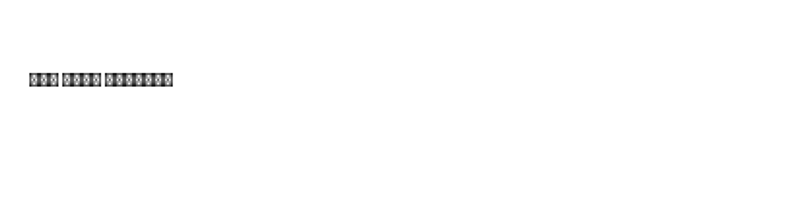

In [12]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("data/raw/synthetic/urdu_1.png")

plt.figure(figsize=(10,3))
plt.imshow(img)
plt.axis("off")